# Point-in-time fundamentals: killing lookahead bias with ASOF joins

Fundamentals have two timestamps: the fiscal date the numbers describe
(`period_end`) and the date the market actually learned them (the report
date, typically 25-55 days later). Index your database by the wrong one and
every backtest silently trades on numbers that did not exist yet — the most
common and most flattering bug in equity research. This recipe stores
fundamentals keyed by *report time*, uses h5i-db's `asof_join` to attach
"latest reported EPS" to a daily price panel, quantifies exactly how much a
`period_end`-keyed join inflates a simple earnings signal, and uses version
pinning to keep a study reproducible after a restatement lands.

In [1]:
import numpy as np
import pandas as pd
import pyarrow as pa

import h5i_db
import cookbook_utils as cu

db = h5i_db.Database(cu.fresh_db("mde_pit"), create=True)

## 1. Data: a price panel that reacts at the *announcement*

`make_fundamentals` generates quarterly EPS with realistic reporting lags —
`ts` is the report timestamp, `period_end` the fiscal date. Its prices are
generated independently of `make_daily_prices`, so out of the box no EPS
signal predicts anything. To make lookahead bias *measurable* we graft in
the one mechanism that matters: on the first session after each report, the
stock jumps 4% in the direction of the EPS surprise (permanently). That is
the textbook announcement reaction — and the honest way to demo the bias:
information is priced in *when it is released*, not when the quarter ended.

In [2]:
SYMS = [f"STK{i:03d}" for i in range(30)]

funda = cu.make_fundamentals(symbols=SYMS, quarters=10).to_pandas()
funda = funda.sort_values(["symbol", "ts"]).reset_index(drop=True)
funda["eps_growth"] = funda.groupby("symbol")["eps"].pct_change().round(4)

daily = cu.make_daily_prices(symbols=SYMS, days=700).to_pandas()

JUMP = 0.04
for r in funda.dropna(subset=["eps_growth"]).itertuples():
    direction = float(np.sign(r.eps_growth))
    if direction == 0.0:
        continue
    mask = (daily["symbol"] == r.symbol) & (daily["ts"] >= r.ts)
    daily.loc[mask, ["open", "high", "low", "close"]] *= 1 + JUMP * direction

print(f"{len(funda)} reports for {len(SYMS)} symbols, "
      f"{funda['ts'].min():%Y-%m-%d} .. {funda['ts'].max():%Y-%m-%d}")
print(f"{len(daily)} daily rows, {daily['ts'].min():%Y-%m-%d} .. {daily['ts'].max():%Y-%m-%d}")

300 reports for 30 symbols, 2023-04-26 .. 2025-08-23
21000 daily rows, 2023-01-02 .. 2025-09-05


The gap between the two timestamps is the whole problem. For one symbol,
each quarter's numbers are "in limbo" for the length of the grey bar — a
`period_end`-keyed join hands your backtest the numbers at the *left* end
of the bar; the market only saw them at the *right* end.

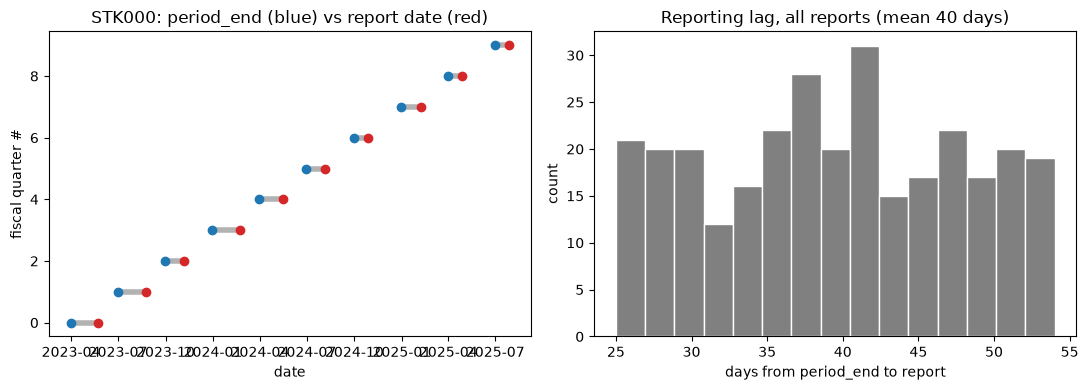

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
f0 = funda[funda["symbol"] == "STK000"].reset_index(drop=True)
for i, r in f0.iterrows():
    axes[0].hlines(i, r["period_end"], r["ts"], color="grey", lw=4, alpha=0.6)
    axes[0].plot(r["period_end"], i, "o", color="tab:blue")
    axes[0].plot(r["ts"], i, "o", color="tab:red")
axes[0].set_title("STK000: period_end (blue) vs report date (red)")
axes[0].set_xlabel("date")
axes[0].set_ylabel("fiscal quarter #")

lags = (funda["ts"] - funda["period_end"]).dt.days
axes[1].hist(lags, bins=15, color="grey", edgecolor="white")
axes[1].set_title(f"Reporting lag, all reports (mean {lags.mean():.0f} days)")
axes[1].set_xlabel("days from period_end to report")
axes[1].set_ylabel("count")
fig.tight_layout()

## 2. Store both tables, keyed by the right clock

The fundamentals table's `time_column` is the **report** timestamp — the
moment each row became public knowledge. `period_end` rides along as an
ordinary column. This single schema decision is what makes every downstream
ASOF query point-in-time by default.

In [4]:
PRICE_SCHEMA = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("symbol", pa.string()),
        pa.field("close", pa.float64()),
        pa.field("volume", pa.int64()),
    ]
)
db.create_table("prices", PRICE_SCHEMA, time_column="ts", sort_key=["ts", "symbol"])
db.append(
    "prices",
    pa.Table.from_pandas(
        daily[["ts", "symbol", "close", "volume"]].sort_values(["ts", "symbol"]), preserve_index=False
    ).cast(PRICE_SCHEMA),
    note="daily closes with announcement reactions",
)

FUNDA_SCHEMA = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),  # report time
        pa.field("period_end", pa.timestamp("us", tz="UTC")),
        pa.field("symbol", pa.string()),
        pa.field("eps", pa.float64()),
        pa.field("eps_growth", pa.float64()),
    ]
)
db.create_table("fundamentals", FUNDA_SCHEMA, time_column="ts", sort_key=["ts", "symbol"])
db.append(
    "fundamentals",
    pa.Table.from_pandas(
        funda[["ts", "period_end", "symbol", "eps", "eps_growth"]].sort_values(["ts", "symbol"]),
        preserve_index=False,
    ).cast(FUNDA_SCHEMA),
    note="as-reported quarterly EPS, 10 quarters",
)

{'table': 'fundamentals',
 'sequence': 1,
 'op': 'append',
 'rows_total': 300,
 'segments_total': 1,
 'segments_added': 1,
 'segments_deduped': 0,
 'committed_at_ns': 1784776156046099224}

Our study rebalances monthly, so the research panel is the month-end cross
section — one `time_bucket('1mo', ...)` rollup, materialized as its own
table. Deriving compact, purpose-built tables from the canonical daily
store is the usual shape of this workflow — and it also respects a
limitation of the current h5i-db build: ASOF joins evaluate on a single
Arrow batch (8,192 rows) per side and *silently truncate* beyond it. Keep
both join sides comfortably below that (here: ~990 month-ends x ~300
reports) and always assert one output row per left row, as we do below.

In [5]:
monthly = db.sql(
    """
    SELECT max(ts)                        AS ts,
           symbol,
           last_value(close ORDER BY ts)  AS close
    FROM prices
    GROUP BY time_bucket('1mo', ts), symbol
    ORDER BY ts, symbol
    """
).to_arrow()

MONTHLY_SCHEMA = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("symbol", pa.string()),
        pa.field("close", pa.float64()),
    ]
)
db.create_table("prices_m", MONTHLY_SCHEMA, time_column="ts", sort_key=["ts", "symbol"])
db.append("prices_m", monthly.cast(MONTHLY_SCHEMA), note="month-end closes derived from prices")
N_MONTHLY = monthly.num_rows
print(f"{N_MONTHLY} month-end observations")

990 month-end observations


## 3. The point-in-time join

`asof_join('prices_m', 'fundamentals', 'ts', 'ts', 'symbol')` attaches, to
each month-end bar, the latest fundamentals row whose *report time* is at or
before that bar — per symbol, streaming on sorted storage, no window
gymnastics. Colliding right-side columns get a `_right` suffix, so the
report timestamp survives as `ts_right`: every row carries its own
"known since" provenance.

In [6]:
pit = db.sql(
    """
    SELECT ts, symbol, close, eps, eps_growth,
           ts_right   AS known_since,
           period_end
    FROM asof_join('prices_m', 'fundamentals', 'ts', 'ts', 'symbol')
    ORDER BY ts, symbol
    """
).to_pandas()
assert len(pit) == N_MONTHLY, f"ASOF returned {len(pit)} rows for {N_MONTHLY} left rows"

# spot-check the ASOF result against an independent point query
probe = pit[pit["symbol"] == "STK005"].iloc[12]
point = db.sql(
    f"""
    SELECT eps FROM fundamentals
    WHERE symbol = 'STK005' AND ts <= '{probe['ts'].isoformat()}'
    ORDER BY ts DESC LIMIT 1
    """
).to_pandas()["eps"][0]
assert point == probe["eps"]

pit[pit["symbol"] == "STK000"].iloc[3:9]

,ts,symbol,close,eps,eps_growth,known_since,period_end
90,2023-04-28 20:00:00+00:00,STK000,15.5100,NaN,NaN,NaT,NaT
120,2023-05-31 20:00:00+00:00,STK000,15.4100,1.99,NaN,2023-05-23 21:00:00+00:00,2023-03-31 00:00:00+00:00
150,2023-06-30 20:00:00+00:00,STK000,15.7800,1.99,NaN,2023-05-23 21:00:00+00:00,2023-03-31 00:00:00+00:00
180,2023-07-31 20:00:00+00:00,STK000,15.6600,1.99,NaN,2023-05-23 21:00:00+00:00,2023-03-31 00:00:00+00:00
210,2023-08-31 20:00:00+00:00,STK000,14.9472,1.92,-0.0352,2023-08-23 21:00:00+00:00,2023-06-30 00:00:00+00:00
240,2023-09-29 20:00:00+00:00,STK000,16.5600,1.92,-0.0352,2023-08-23 21:00:00+00:00,2023-06-30 00:00:00+00:00


A `tolerance` (raw microseconds) caps staleness: with a 120-day limit,
month-ends whose latest report is older than ~a quarter and a half get NULLs
instead of a zombie EPS — useful for flagging delisted names or late filers.

In [7]:
TOL_US = 120 * 86_400 * 1_000_000
db.sql(
    f"""
    SELECT count(*)                                          AS month_ends,
           sum(CASE WHEN eps IS NULL THEN 1 ELSE 0 END)      AS no_fresh_report
    FROM asof_join('prices_m', 'fundamentals', 'ts', 'ts', 'symbol', 'backward', {TOL_US})
    """
).to_pandas()

,month_ends,no_fresh_report
0,990,116


## 4. The wrong join, and what it costs

The classic mistake is joining on `period_end` — as if numbers were known
the night the quarter closed. `asof_join` takes any right-side time column,
so the buggy version is one argument away (our reporting lags keep
`period_end` monotone in report order, which the join requires). First, the
mechanical size of the leak:

In [8]:
ahead = db.sql(
    """
    SELECT ts, symbol, close, eps AS eps_ahead, eps_growth AS growth_ahead
    FROM asof_join('prices_m', 'fundamentals', 'ts', 'period_end', 'symbol')
    ORDER BY ts, symbol
    """
).to_pandas()
assert len(ahead) == N_MONTHLY

panel = pit.merge(ahead[["ts", "symbol", "eps_ahead", "growth_ahead"]], on=["ts", "symbol"])
both = panel.dropna(subset=["eps", "eps_ahead"])
leak = (both["eps"] != both["eps_ahead"]).mean()
print(f"{leak:.1%} of month-end observations see a *different* EPS under the period_end join")
print(f"on those, the join is early by up to the reporting lag (mean {lags.mean():.0f} days)")

40.6% of month-end observations see a *different* EPS under the period_end join
on those, the join is early by up to the reporting lag (mean 40 days)


Now the damage in signal terms. Take the simplest earnings signal — the sign
of QoQ EPS growth — and relate it to the *forward* 21-session return,
measured relative to the cross-sectional mean (market-relative, so the
common factor and its handful of effective observations don't drown the
comparison). The point-in-time signal knows nothing: the announcement pop
is already in the price by the time the signal exists. The lookahead signal
"predicts" the pop it peeked at:

In [9]:
fut = daily.sort_values(["symbol", "ts"]).copy()
fut["fwd21"] = fut.groupby("symbol")["close"].transform(lambda s: s.shift(-21) / s - 1)
panel = panel.merge(fut[["ts", "symbol", "fwd21"]], on=["ts", "symbol"], how="left")
panel["fwd21_rel"] = panel["fwd21"] - panel.groupby("ts")["fwd21"].transform("mean")

rows = []
for label, col in [("point-in-time", "eps_growth"), ("lookahead", "growth_ahead")]:
    d = panel.dropna(subset=[col, "fwd21_rel"])
    d = d[d[col] != 0]
    sig = np.sign(d[col])
    up, dn = d.loc[sig > 0, "fwd21_rel"].mean(), d.loc[sig < 0, "fwd21_rel"].mean()
    rows.append(
        {
            "join": label,
            "corr(sign, fwd ret)": round(float(np.corrcoef(sig, d["fwd21_rel"])[0, 1]), 3),
            "fwd_ret_eps_up_pct": round(100 * up, 2),
            "fwd_ret_eps_down_pct": round(100 * dn, 2),
            "spread_pct": round(100 * (up - dn), 2),
        }
    )
bias = pd.DataFrame(rows).set_index("join")
bias

,"corr(sign, fwd ret)",fwd_ret_eps_up_pct,fwd_ret_eps_down_pct,spread_pct
join,,,,
point-in-time,-0.021,-0.19,0.15,-0.33
lookahead,0.133,0.95,-1.12,2.07


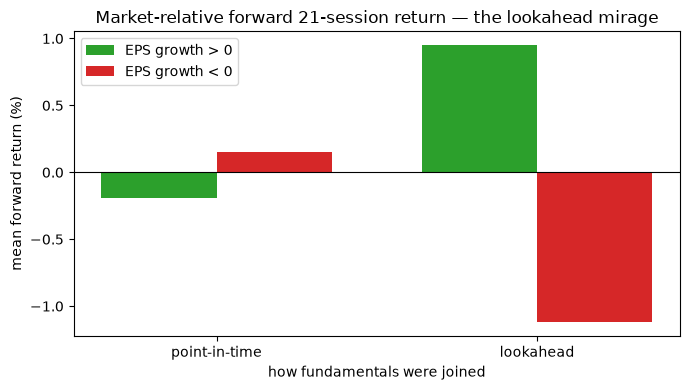

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(2)
ax.bar(x - 0.18, bias["fwd_ret_eps_up_pct"], 0.36, label="EPS growth > 0", color="tab:green")
ax.bar(x + 0.18, bias["fwd_ret_eps_down_pct"], 0.36, label="EPS growth < 0", color="tab:red")
ax.set_xticks(x, bias.index)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Market-relative forward 21-session return — the lookahead mirage")
ax.set_xlabel("how fundamentals were joined")
ax.set_ylabel("mean forward return (%)")
ax.legend()
fig.tight_layout()

The entire "alpha" of the lookahead variant is the announcement reaction it
saw before the market did. Same data, same signal, one wrong timestamp —
and a spread appears out of nowhere. On real data this is exactly how
too-good-to-be-true fundamental backtests are born.

## 5. Restatements: reproducing the original study

Fundamentals get restated. In an append-keyed PIT table a restatement is a
*new row at its own report time* — history is never edited, so the old view
remains queryable. Suppose STK003's latest EPS is revised up 35% after an
audit adjustment:

In [11]:
v_study = db.versions("fundamentals")[-1]["sequence"]  # pin: the version our study used

last = funda[funda["symbol"] == "STK003"].iloc[-1]
restated = pa.table(
    {
        "ts": pa.array([funda["ts"].max() + pd.Timedelta(days=3)], pa.timestamp("us", tz="UTC")),
        "period_end": pa.array([last["period_end"]], pa.timestamp("us", tz="UTC")),
        "symbol": ["STK003"],
        "eps": [round(last["eps"] * 1.35, 2)],
        "eps_growth": [None],
    }
).cast(FUNDA_SCHEMA)
db.append("fundamentals", restated, note="STK003 EPS restated +35% (audit adjustment)")

db.sql(
    f"""
    SELECT 'head (post-restatement)' AS view, eps, ts AS known_since
    FROM fundamentals
    WHERE symbol = 'STK003' ORDER BY ts DESC LIMIT 1
    """
).to_pandas()

,view,eps,known_since
0,head (post-restatement),2.3,2025-08-26 21:00:00+00:00


In [12]:
db.sql(
    f"""
    SELECT 'pinned v{v_study} (as studied)' AS view, eps, ts AS known_since
    FROM h5i('fundamentals', {v_study})
    WHERE symbol = 'STK003' ORDER BY ts DESC LIMIT 1
    """
).to_pandas()

,view,eps,known_since
0,pinned v1 (as studied),1.7,2025-08-16 21:00:00+00:00


Recording `v_study` (or a named snapshot) alongside a research run means the
study re-executes against byte-identical inputs forever — the restatement
lands for live use without rewriting your paper trail. Note `asof_join`
operates on table *heads*; to rebuild a full pinned panel, read the pinned
version (`db.read("fundamentals", version=v_study)` or `h5i(...)` in SQL)
and join against that.

## Takeaways

- Key fundamentals by **report time**; keep `period_end` as payload. That
  one schema decision makes every `asof_join` point-in-time by default.
- `asof_join(prices, fundamentals, 'ts', 'ts', 'symbol')` is the whole PIT
  machinery: per-symbol latest-known-value, with `ts_right` as built-in
  "known since" provenance and `tolerance` to refuse stale numbers.
- Joining on `period_end` handed a do-nothing signal a fat announcement-pop
  spread — lookahead bias measured, not just asserted.
- Restatements are appends, not edits; pinning a version (`h5i('t', v)`,
  `read(version=)`) reproduces the original study exactly while the head
  serves the corrected view.

In [13]:
db.close()